<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/LINEA_DE_ESPERA_dos_Servidores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### <span style="color:teal;">**6.3 Sistema de línea de espera con dos servidores en serie** (libro de Ross)</span>



<span style="color:coffee;">**Nombre:** </span> FLORENCIO FLORENCIO MIRIAM LIZETH

<span style="color:purple;"> **Objetivo:**</span>

El objetivo de un sistema de líneas de espera con dos servidores, ya sea en serie o en paralelo, es analizar el flujo de entidades (clientes, piezas, trabajos, llamadas, entre otros) a través del sistema, así como evaluar medidas de desempeño relevantes, tales como los tiempos de espera, la utilización de los servidores y la longitud de las colas.

**En este estudio se considera un sistema de dos servidores en el que las llegadas de los clientes siguen un proceso de Poisson no homogéneo. Se supone además que cada cliente debe ser atendido inicialmente por el Servidor $1$ y, una vez concluido dicho servicio, pasa al Servidor $2$ para completar su atención.**

**Este tipo de configuración se conoce como sistema de colas en tándem o sistema secuencial, ya que los clientes deben atravesar de manera consecutiva ambas etapas de servicio antes de abandonar el sistema. El análisis de este modelo permite estudiar el comportamiento dinámico de las colas, identificar posibles cuellos de botella y evaluar la eficiencia global del proceso de atención.**

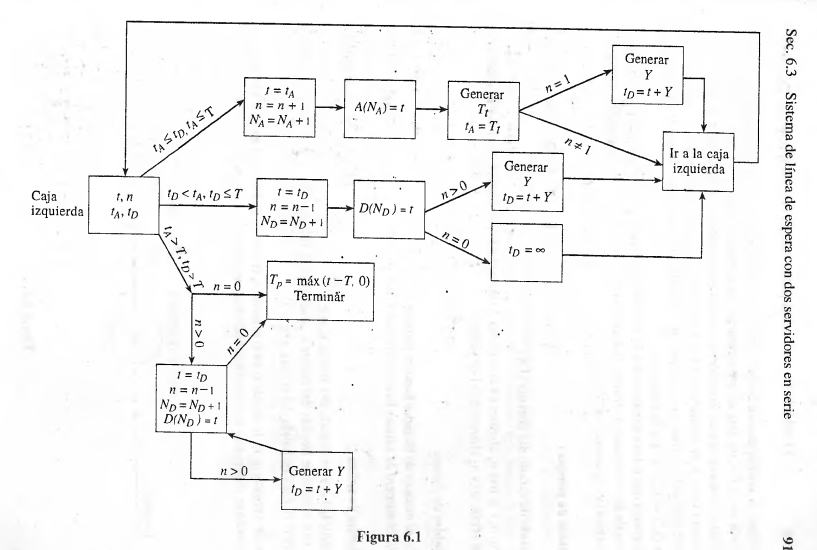

Al llegar, el cliente pasará con el servidor 1 si éste se encuentra desocupado, o se formará en la fila de éste en caso contrario. De manera análoga, cuando el cliente termine el servicio en el servidor 1, entra a servicio con el servidor 2 si éste se encuentra libre, o se formará en su fila. Después de ser atendido en el servidor 2, el cliente sale del sistema. Los tiempos de servicio en el servidor $i$ tienen la distribución $G_i$, $i = 1,2$ (véase la figura 6.2).

Suponga que estamos interesados en realizar una simulación para estudiar la distribución de las cantidades de tiempo que un cliente pasa en ambos servidores. Para esto, utilizamos las siguientes variables.

**Variable de tiempo**

* $t$

**Variable de estado del sistema (ES)**

* $(n_1, n_2)$:

si hay $n_1$ clientes en el servidor 1 (incluyendo los formados y los que están en servicio) y $n_2$ clientes en el servidor 2.

**Variables de conteo**

* $N_A$: el número de llegadas hasta el instante $t$

* $N_D$: el número de salidas hasta el instante $t$

**Variables de salida**

* $A_1(n)$: la hora de llegada del cliente $n$, $n \geq 1$

* $A_2(n)$: la hora de llegada del cliente $n$ al servidor 2, $n \geq 1$

* $D(n)$: la hora de salida del cliente $n$, $n \geq 1$

**Lista de eventos**

$t_A, t_1, t_2$, donde $t_A$ es la hora de la siguiente llegada y $t_i$ es la hora a la que concluye el servicio del cliente actualmente atendido por el servidor $i$, $i = 1,2$.

Si en un momento dado no se encuentra un cliente con el servidor $i$, entonces

$$
t_i = \infty, \quad i = 1,2.
$$

La lista de eventos siempre consta de las tres variables $t_A$, $t_1$, $t_2$.

Para comenzar la simulación, inicializamos las variables y la lista de eventos como sigue:

**Inicialización**

Sean

$$
t = N_A = N_D = 0.
$$

Sea el estado del sistema

$$
ES = (0,0).
$$

Generar $T_0$ y hacer

$$
t_A = T_0,
\qquad
t_1 = t_2 = \infty.
$$

Para actualizar el sistema, nos movemos en el tiempo hasta encontrar el siguiente evento. Debemos considerar diversos casos, dependiendo del mínimo de los miembros de la lista de eventos. En lo sucesivo, $Y_i$ se refiere a una variable aleatoria con distribución $G_i$, $i=1,2$.

$$
ES=(n_1,n_2)
\qquad
LE=t_A,t_1,t_2
$$

* **Caso 1**

$$
t_A=\min(t_A,t_1,t_2)
$$

Restablecer:

$$
t=t_A
$$

Restablecer:

$$
N_A=N_A+1
$$

Restablecer:

$$
n_1=n_1+1
$$

Generar $T_r$ y hacer

$$
t_A=T_r
$$

Si $n_1=1$, generar $Y_1$ y hacer

$$
t_1=t+Y_1
$$

Reunir los datos de salida

$$
A_1(N_A)=t
$$

* **Caso 2**

$$
t_1<t_A,\qquad t_1\le t_2
$$

Restablecer:

$$
t=t_1
$$

Restablecer:

$$
n_1=n_1-1,
\qquad
n_2=n_2+1
$$

Si $n_1=0$, hacer

$$
t_1=\infty
$$

En caso contrario, generar $Y_1$ y hacer

$$
t_1=t+Y_1
$$

Si $n_2=1$, generar $Y_2$ y hacer

$$
t_2=t+Y_2
$$

Reunir los datos de salida

$$
A_2(N_A-n_1)=t
$$

* **Caso 3**

$$
t_2<t_A,\qquad t_2<t_1
$$

Restablecer:

$$
t=t_2
$$

Restablecer:

$$
N_D=N_D+1
$$

Restablecer:

$$
n_2=n_2-1
$$

Si $n_2=0$, hacer

$$
t_2=\infty
$$

Si $n_2>0$, generar $Y_2$ y hacer

$$
t_2=t+Y_2
$$

Reunir los datos de salida

$$
D(N_D)=t
$$

Con este esquema de actualización, es fácil simular el sistema y reunir los datos de importancia.

In [50]:
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt

In [53]:
@dataclass
class EstadoSistema:

   # Estado del sistema.

   # n1 : clientes en servidor 1
      #   (en cola + servicio)

   # n2 : clientes en servidor 2
      #   (en cola + servicio)

  #  NA : número de llegadas

    #ND : número de salidas

   # t  : tiempo actual


    n1: int = 0
    n2: int = 0

    NA: int = 0
    ND: int = 0

    t: float = 0.0

In [33]:
def generar_servicio2(mu2):
   #
   # Tiempo de servicio en servidor 2.
  #
    return np.random.exponential(1/mu2)

In [41]:
def inicializar(lamb):
  #
    #Inicializa variables del sistema.
   #

    estado = EstadoSistema()

    # Próxima llegada
    tA = generar_llegada(lamb)

    # No hay clientes en servicio
    t1 = np.inf
    t2 = np.inf

    return estado, tA, t1, t2

In [42]:
def evento_llegada(
        estado,
        tA,
        t1,
        t2,
        lamb,
        mu1,
        A1):

   # Procesa una llegada al sistema.


    estado.t = tA

    estado.NA += 1

    estado.n1 += 1

    cliente = estado.NA

    # Registrar hora de llegada
    A1[cliente] = estado.t

    # Programar siguiente llegada
    tA = estado.t + generar_llegada(lamb)

    # Si servidor 1 estaba vacío
    if estado.n1 == 1:

        y1 = generar_servicio1(mu1)

        t1 = estado.t + y1

    return tA, t1, t2

In [43]:
def evento_servidor1(
        estado,
        tA,
        t1,
        t2,
        mu1,
        mu2,
        A2):

   # Cliente termina servicio en servidor 1.


    estado.t = t1

    estado.n1 -= 1
    estado.n2 += 1

    # Servidor 1
    if estado.n1 == 0:

        t1 = np.inf

    else:

        y1 = generar_servicio1(mu1)

        t1 = estado.t + y1

    # Servidor 2
    if estado.n2 == 1:

        y2 = generar_servicio2(mu2)

        t2 = estado.t + y2

    cliente = estado.NA - estado.n1

    A2[cliente] = estado.t

    return tA, t1, t2

In [44]:
def evento_servidor2(
        estado,
        tA,
        t1,
        t2,
        mu2,
        D):

   # Cliente abandona el sistema.

    estado.t = t2

    estado.ND += 1

    estado.n2 -= 1

    cliente = estado.ND

    D[cliente] = estado.t

    if estado.n2 == 0:

        t2 = np.inf

    else:

        y2 = generar_servicio2(mu2)

        t2 = estado.t + y2

    return tA, t1, t2

In [45]:
def simular_tandem(
        lamb,
        mu1,
        mu2,
        n_clientes):

    #Simulación de cola en serie con dos servidores.


    estado, tA, t1, t2 = inicializar(lamb)

    A1 = {}
    A2 = {}
    D = {}

    while estado.ND < n_clientes:

        minimo = min(tA, t1, t2)

        # Caso 1
        if minimo == tA:

            tA, t1, t2 = evento_llegada(
                estado,
                tA,
                t1,
                t2,
                lamb,
                mu1,
                A1
            )

        # Caso 2
        elif minimo == t1:

            tA, t1, t2 = evento_servidor1(
                estado,
                tA,
                t1,
                t2,
                mu1,
                mu2,
                A2
            )

        # Caso 3
        else:

            tA, t1, t2 = evento_servidor2(
                estado,
                tA,
                t1,
                t2,
                mu2,
                D
            )

    return A1, A2, D

In [46]:
def generar_llegada(lamb):

    #Tiempo entre llegadas.

    return np.random.exponential(1/lamb)

def generar_servicio1(mu1):

    #Tiempo de servicio en servidor 1.

    return np.random.exponential(1/mu1)

np.random.seed(123)

A1, A2, D = simular_tandem(
    lamb=2,
    mu1=3,
    mu2=4,
    n_clientes=10
)

print("Llegadas al sistema")
for k, v in A1.items():
    print(k, round(v,4))

print("\nLlegadas al servidor 2")
for k, v in A2.items():
    print(k, round(v,4))

print("\nSalidas del sistema")
for k, v in D.items():
    print(k, round(v,4))

Llegadas al sistema
1 0.5961
2 0.7647
3 1.4002
4 1.9775
5 2.1877
6 2.4763
7 3.146
8 3.5255
9 4.17
10 4.365
11 4.5389
12 4.5872

Llegadas al servidor 2
1 0.6819
2 0.948
3 1.6188
4 2.4128
5 2.4333
6 2.5435
7 3.4814
8 3.8402
9 4.3197
10 4.6973

Salidas del sistema
1 0.8823
2 1.9358
3 2.0602
4 2.5397
5 2.5879
6 2.7775
7 3.9548
8 4.2752
9 4.3845
10 4.8675


In [20]:
W1 = {
    n: A2[n]-A1[n]
    for n in A2
}

In [47]:
W2 = {
    n: D[n]-A2[n]
    for n in D
}

In [48]:
T = {
    n: D[n]-A1[n]
    for n in D
}

print(
    "Tiempo promedio en sistema:",
    np.mean(list(T.values()))
)

Tiempo promedio en sistema: 0.5656187707299114


Para comprender mejor el comportamiento del sistema, resulta útil analizar los resultados de manera gráfica:

* Tiempo total en el sistema por cliente: esta gráfica muestra el tiempo que cada cliente permanece dentro del sistema, desde su llegada hasta que finaliza su atención. De esta manera, es posible evaluar la experiencia individual de los clientes y detectar posibles retrasos.
* Comparación de los tiempos de atención en el Servidor 1 y el Servidor 2: esta representación permite comparar el desempeño de ambos servidores, identificando si alguno genera mayores tiempos de espera o si existe un posible cuello de botella que afecte la eficiencia del sistema.

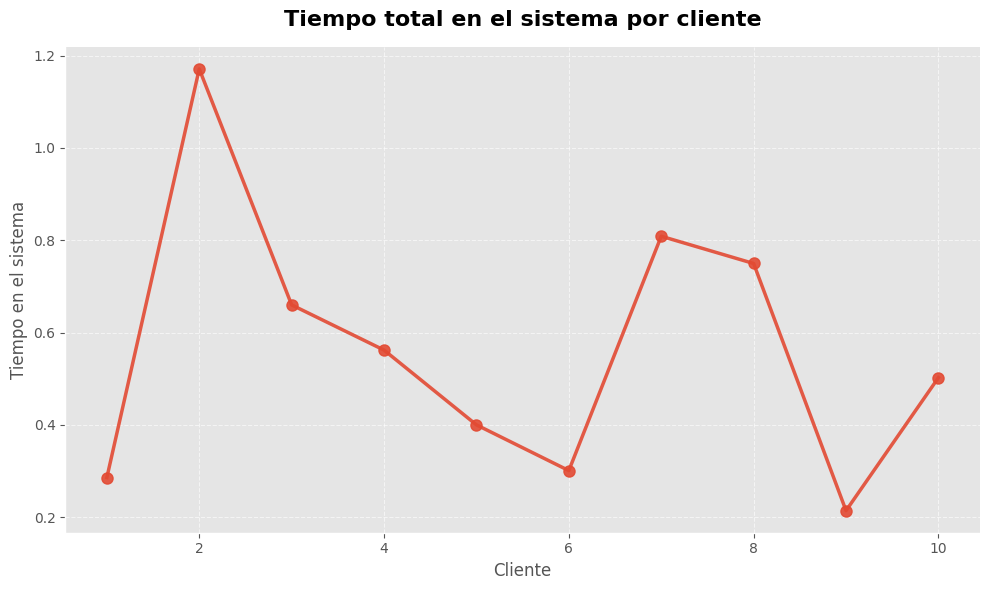

In [54]:
# GRÁFICA

# Datos
clientes = list(T.keys())
tiempos = list(T.values())

# Estilo
plt.style.use('ggplot')

plt.figure(figsize=(10,6))

plt.plot(
    clientes,
    tiempos,
    marker='o',
    markersize=8,
    linewidth=2.5,
    alpha=0.9
)

plt.title(
    'Tiempo total en el sistema por cliente',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Cliente', fontsize=12)
plt.ylabel('Tiempo en el sistema', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

# Eliminar bordes innecesarios
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

La gráfica muestra el tiempo total que cada cliente permaneció en el sistema. Se observa una variabilidad considerable entre clientes, destacando el cliente $2$ con el mayor tiempo de permanencia. Asimismo, los clientes $7$ y $8$ presentan tiempos relativamente elevados, mientras que el cliente $9$ registra el menor valor.

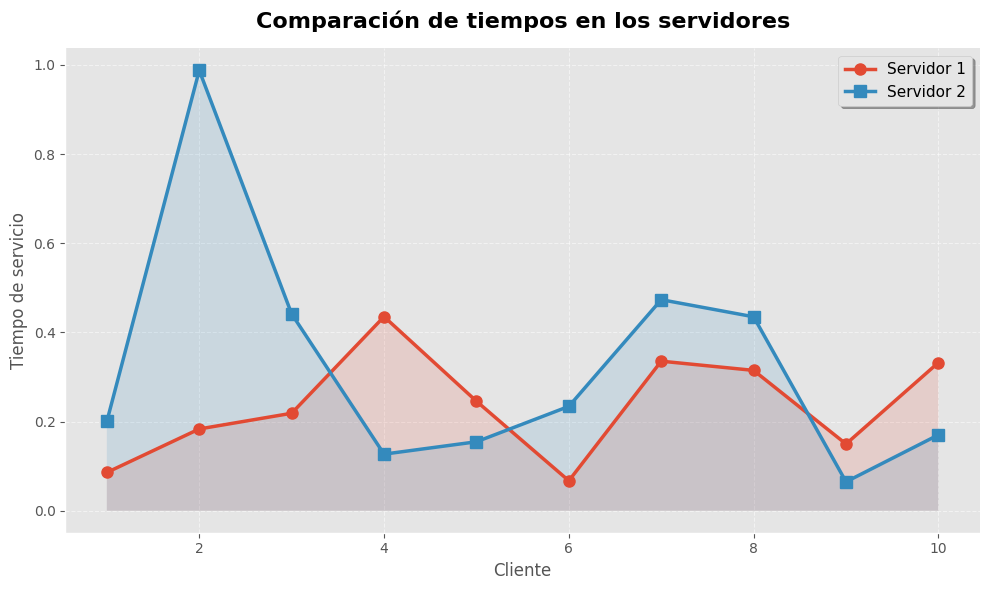

In [55]:
# GRÁFICA

clientes = list(W1.keys())

plt.figure(figsize=(10,6))

plt.plot(
    clientes,
    list(W1.values()),
    marker='o',
    markersize=8,
    linewidth=2.5,
    label='Servidor 1'
)

plt.plot(
    clientes,
    list(W2.values()),
    marker='s',
    markersize=8,
    linewidth=2.5,
    label='Servidor 2'
)

plt.fill_between(
    clientes,
    list(W1.values()),
    alpha=0.15
)

plt.fill_between(
    clientes,
    list(W2.values()),
    alpha=0.15
)

plt.title(
    'Comparación de tiempos en los servidores',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Cliente', fontsize=12)
plt.ylabel('Tiempo de servicio', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(
    fontsize=11,
    frameon=True,
    shadow=True
)

# Eliminar bordes innecesarios
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

La gráfica compara los tiempos de servicio registrados en ambos servidores para cada cliente atendido. Se observa que el Servidor $1$ presenta tiempos más homogéneos y estables, mientras que el Servidor $2$ muestra una mayor variabilidad, incluyendo algunos tiempos de servicio considerablemente más altos.

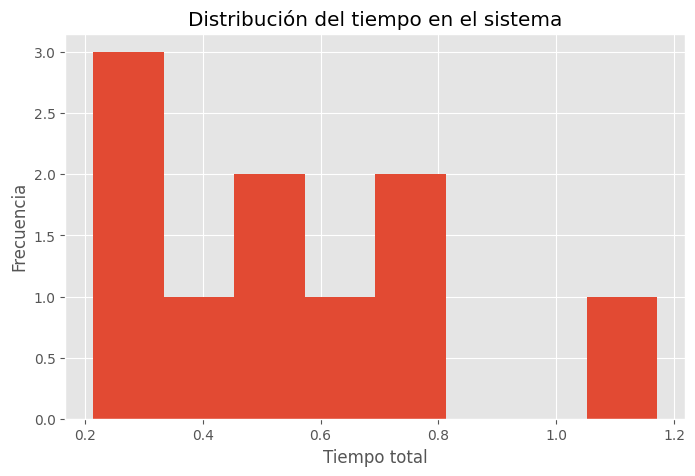

In [56]:
plt.figure(figsize=(8,5))

plt.hist(list(T.values()),
         bins=8)

plt.xlabel('Tiempo total')
plt.ylabel('Frecuencia')
plt.title('Distribución del tiempo en el sistema')
plt.grid(True)

plt.show()

El histograma muestra la distribución de los tiempos totales que los clientes permanecieron en el sistema. Se observa que la mayor parte de los clientes registró tiempos relativamente bajos, concentrados entre $0.2$ y $0.4$ unidades de tiempo. Asimismo, la distribución presenta una ligera asimetría hacia la derecha, indicando la existencia de algunos clientes que experimentaron tiempos de permanencia más elevados. Esto sugiere que el sistema opera de manera eficiente para la mayoría de los clientes, aunque ocasionalmente pueden presentarse demoras mayores debido a la dinámica de la cola y la ocupación de los servidores.

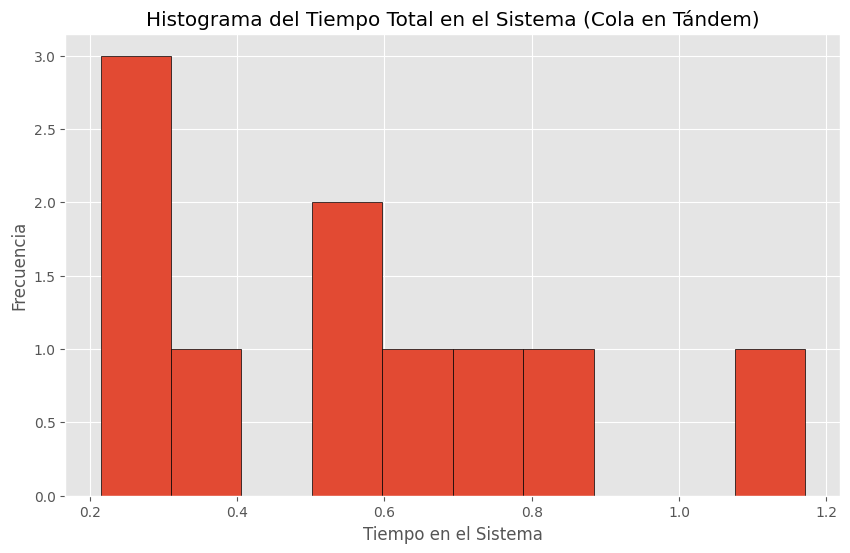

In [27]:


# Histograma del tiempo total en el sistema (T)
plt.figure(figsize=(10, 6))
plt.hist(list(T.values()), bins=10, edgecolor='black')
plt.title('Histograma del Tiempo Total en el Sistema (Cola en Tándem)')
plt.xlabel('Tiempo en el Sistema')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

 Este histograma muestra la distribución del tiempo total que cada cliente pasó en el sistema de cola en tándem.

### <span style="color:teal;">**6.4 Sistema de línea de espera con dos servidores en paralelo** (libro de Ross)</span>

**Consideremos un modelo en el que los clientes llegan a un sistema con dos servidores.**

**Al llegar, un cliente se forma en una fila si ambos servidores están ocupados, entra a servicio con el servidor 1 si ese servidor está desocupado, o bien con el servidor 2 en
caso contrario.** **Cuando el cliente concluye el servicio con un servidor (sin importar cuál
sea), sale del sistema y el cliente que ha estado formado más tiempo (si hay clientes en
la cola) entra a servicio. La distribución de servicio en el servidor $i$ es $G_i$,
$i = 1, 2$ (véase la figura 6.3).**

**Suponga que queremos simular el modelo anterior manteniendo un registro de las
cantidades de tiempo que pasa cada cliente dentro del sistema y el número de servicios
realizados por cada servidor. Como hay varios servidores, los clientes no saldrán en el
orden de llegada. Por lo tanto, para saber qué cliente es el sistema al concluir su
servicio, necesitaremos llevar un registro para ver qué clientes están en el sistema. Así,
los numeraremos conforme vayan llegando, de modo que el primero en llegar es el cliente
número 1, el siguiente es el número 2, y así sucesivamente. Utilizaremos las siguientes
variables:**


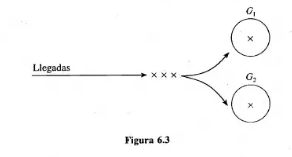

* **Variable de tiempo**

$$
t
$$

* **Variable de estado del sistema (ES)**

$$
(n,\, i_1,\, i_2,\, \ldots,\, i_s)
$$

si hay $n$ clientes en el sistema, $i_1$ está con el servidor 1,
$i_2$ está con el servidor 2, $i_3$ es el primero de la fila,
$i_4$ es el siguiente, y así sucesivamente.

Observe que

$$
ES=(0)
$$

cuando el sistema está vacío, y

$$
ES=(1,j,0)
$$

o

$$
(1,0,j)
$$

cuando el único cliente es $j$ y éste está siendo atendido por el
servidor 1 o el 2, respectivamente.

* **Variables de conteo**

$$
N_A:
$$

el número de llegadas hasta el instante $t$
$$
C_j:
$$

el número de clientes atendidos por $j$,
$j=1,2$, hasta el instante $t$

* **Variables de salida**

$$
A(n):
$$

la hora de llegada del cliente $n$,
$n \geq 1$

$$
D(n):
$$

la hora de salida del cliente $n$,
$n \geq 1$

**Lista de eventos**

$$
t_A,\; t_1,\; t_2
$$

Donde $t_A$ es la hora de la siguiente llegada y $t_j$ es la hora en la
que concluye el servicio del cliente que en ese momento está siendo
atendido por el servidor $j$, $j=1,2$. Si no hay un cliente actualmente
con el servidor $i$, entonces hacemos

$$
t_i=\infty, \qquad i=1,2.
$$

En lo sucesivo, la lista de eventos siempre constará de las tres
variables $t_A$, $t_1$, $t_2$.

Para comenzar la simulación, inicializamos las variables y la lista de
eventos como sigue:



* **Inicialización**

Hacer

$$
t = N_A = C_1 = C_2 = 0.
$$

Hacer

$$
ES = (0).
$$

Generar $T_A$ y hacer

$$
t_A = T_A, \qquad t_1 = T_2 = \infty.
$$

Para actualizar el sistema, nos movemos en el tiempo hasta encontrar el
siguiente evento. En los siguientes casos, $Y_i$ siempre se refiere a una
variable aleatoria con distribución $G_i$, $i=1,2$.



1. **Caso 1**

$$
ES=(n,i_1,i_2,\ldots,i_n)
$$

y

$$
t_A=\min(t_A,t_1,t_2)
$$

Restablecer:

$$
t=t_A.
$$

Restablecer:

$$
N_A=N_A+1.
$$

Generar $T_A$ y hacer

$$
t_A=t+T_A.
$$

Reunir los datos de salida

$$
A(N_A)=t.
$$



Si

$$
ES=(0):
$$

$$
ES=(1,N_A,0).
$$

Generar $Y_1$ y hacer

$$
t_1=t+Y_1.
$$



Si

$$
ES=(1,j,0):
$$

Restablecer:

$$
ES=(2,j,N_A).
$$

Generar $Y_2$ y hacer

$$
t_2=t+Y_2.
$$



Si

$$
ES=(1,0,j):
$$

Restablecer:

$$
ES=(2,N_A,j).
$$

Generar $Y_1$ y hacer

$$
t_1=t+Y_1.
$$



Si

$$
n>1:
$$

Restablecer:

$$
ES=(n+1,i_1,\ldots,i_n,N_A).
$$


2. **Caso 2**

$$
ES=(n,i_1,i_2,\ldots,i_n)
$$

y

$$
t_1<t_A \quad \text{y} \quad t_1\leq t_2
$$

Restablecer:

$$
t=t_1.
$$

Restablecer:

$$
C_1=C_1+1.
$$

Reunir los datos de salida

$$
D(i_1)=t.
$$



Si

$$
n_1=1:
$$

Restablecer:

$$
ES=(0).
$$

Restablecer:

$$
t_1=\infty.
$$



Si

$$
n_1=2:
$$

Restablecer:

$$
ES=(1,0,i_2).
$$

Restablecer:

$$
t_1=\infty.
$$



Si

$$
n > 2:
$$

Restablecer:

$$
ES=(n-1,i_3,i_2,\ldots,i_n).
$$

Generar $Y_1$ y hacer

$$
t_1=t+Y_1.
$$



3. **Caso 3**

$$
ES=(n,i_1,i_2,\ldots,i_n)
$$

y

$$
t_2<t_A,\quad t_2<t_1.
$$

Las actualizaciones en el caso 3 se dejan como ejercicio.



Si simulamos el sistema de acuerdo con lo anterior y detenemos la
simulación en algún punto final determinado de antemano, entonces
podemos utilizar las variables de salida, al igual que los valores
finales de las variables de conteo $C_1$ y $C_2$ para obtener los
datos relativos a las horas de llegada y salida de los diversos
clientes, así como el número de servicios de cada servidor.

In [28]:
import numpy as np


In [59]:
# Estado del sistema:
#
# ES = (n, i1, i2, i3, ..., in)
#
# n  = número de clientes en el sistema
# i1 = cliente en servidor 1
# i2 = cliente en servidor 2
# i3 = primero en cola
# i4 = segundo en cola
# etc.
#


np.random.seed(123)


# PARÁMETROS


TMAX = 20      # tiempo máximo de simulación
lam = 3        # tasa de llegadas


# DISTRIBUCIONES


def generar_TA(lam):

    #Distribución de llegadas

   # Parámetros
    #----------
    #lam : float
     #   Tasa de llegadas
    #Tiempo entre llegadas.

    #TA ~ Exp(lam)

    return np.random.exponential(1 / lam)


def generar_Y1():

  #  Distribución G1 (Servidor 1)

   # Puede modificarse según el problema.

    mu1 = 4
    return np.random.exponential(1 / mu1)


def generar_Y2():

    #Distribución G2 (Servidor 2)

    #Puede modificarse según el problema.

    mu2 = 5
    return np.random.exponential(1 / mu2)

# INICIALIZACIÓN


t = 0

NA = 0
C1 = 0
C2 = 0

# Estado inicial ES=(0)

ES = [0]

# Variables de salida

A = {}     # horas de llegada
D = {}     # horas de salida

# Lista de eventos

TA = generar_TA(lam)

tA = TA
t1 = np.inf
t2 = np.inf

# Para la gráfica N(t)
historial_t = []
historial_n = []

# IMPRESIÓN DE INICIO

print("=" * 80)
print("INICIO DE LA SIMULACIÓN")
print("=" * 80)

print(f"t  = {t}")
print(f"NA = {NA}")
print(f"C1 = {C1}")
print(f"C2 = {C2}")

print(f"ES = {ES}")

print(f"tA = {tA:.4f}")
print(f"t1 = {t1}")
print(f"t2 = {t2}")

print()

# CICLO PRINCIPAL


while t < TMAX:


    # CASO 1
    #
    # tA = min(tA,t1,t2)


    if tA <= t1 and tA <= t2:

        t = tA


        # Llegada de un cliente

        NA = NA + 1

        cliente = NA

        # Registrar llegada

        A[cliente] = t

        # Programar siguiente llegada

        TA = generar_TA(lam)

        tA = t + TA


        # ES=(0)


        if ES[0] == 0:

            ES = [1, cliente, 0]

            Y1 = generar_Y1()

            t1 = t + Y1


        # ES=(1,j,0)

        elif ES[0] == 1 and ES[2] == 0:

            j = ES[1]

            ES = [2, j, cliente]

            Y2 = generar_Y2()

            t2 = t + Y2


        # ES=(1,0,j)


        elif ES[0] == 1 and ES[1] == 0:

            j = ES[2]

            ES = [2, cliente, j]

            Y1 = generar_Y1()

            t1 = t + Y1

        # n > 1


        else:

            ES[0] += 1

            ES.append(cliente)


        # IMPRESIÓN DEL EVENTO

        print("=" * 80)
        print("CASO 1: LLEGADA")
        print("=" * 80)

        print(f"Tiempo actual t = {t:.4f}")
        print(f"Cliente que llega = {cliente}")

        print(f"NA = {NA}")

        print("Estado actualizado:")

        print(f"ES = {ES}")

        print(f"Próxima llegada (tA) = {tA:.4f}")
        print(f"Fin servidor 1 (t1) = {t1}")
        print(f"Fin servidor 2 (t2) = {t2}")

        print()
        historial_t.append(t)
        historial_n.append(ES[0])

    # CASO 2
    #
    # t1 < tA
    # t1 <= t2


    elif t1 < tA and t1 <= t2:

        t = t1

        n = ES[0]

        i1 = ES[1]

        C1 = C1 + 1

        D[i1] = t


        # n = 1


        if n == 1:

            ES = [0]

            t1 = np.inf

        # n = 2

        elif n == 2:

            i2 = ES[2]

            ES = [1, 0, i2]

            t1 = np.inf


        # n > 2


        else:

            i2 = ES[2]
            i3 = ES[3]

            nueva_ES = [n - 1]

            nueva_ES.append(i3)
            nueva_ES.append(i2)

            for k in range(4, len(ES)):
                nueva_ES.append(ES[k])

            ES = nueva_ES

            Y1 = generar_Y1()

            t1 = t + Y1

        # IMPRESIÓN DEL EVENTO

        print("=" * 80)
        print("CASO 2: FIN DE SERVICIO EN SERVIDOR 1")
        print("=" * 80)

        print(f"Tiempo actual = {t:.4f}")

        print(f"Cliente que sale = {i1}")

        print(f"C1 = {C1}")

        print(f"D({i1}) = {t:.4f}")

        print("Estado actualizado:")

        print(f"ES = {ES}")

        print(f"tA = {tA:.4f}")
        print(f"t1 = {t1}")
        print(f"t2 = {t2}")

        print()
        historial_t.append(t)
        historial_n.append(ES[0])

    # CASO 3
    #
    # t2 < tA
    # t2 < t1


    else:

        t = t2

        n = ES[0]

        i2 = ES[2]

        C2 = C2 + 1

        D[i2] = t

        # n = 1

        if n == 1:

            ES = [0]

            t2 = np.inf


        # n = 2


        elif n == 2:

            i1 = ES[1]

            ES = [1, i1, 0]

            t2 = np.inf


        # n > 2


        else:

            i1 = ES[1]
            i3 = ES[3]

            nueva_ES = [n - 1]

            nueva_ES.append(i1)
            nueva_ES.append(i3)

            for k in range(4, len(ES)):
                nueva_ES.append(ES[k])

            ES = nueva_ES

            Y2 = generar_Y2()

            t2 = t + Y2

        # IMPRESIÓN DEL EVENTO


        print("=" * 80)
        print("CASO 3: FIN DE SERVICIO EN SERVIDOR 2")
        print("=" * 80)

        print(f"Tiempo actual = {t:.4f}")

        print(f"Cliente que sale = {i2}")

        print(f"C2 = {C2}")

        print(f"D({i2}) = {t:.4f}")

        print("Estado actualizado:")

        print(f"ES = {ES}")

        print(f"tA = {tA:.4f}")
        print(f"t1 = {t1}")
        print(f"t2 = {t2}")

        print()
        historial_t.append(t)
        historial_n.append(ES[0])


# CÁLCULO DE ESTADÍSTICAS

tiempos_sistema = []

for cliente in sorted(D.keys()):

    tiempos_sistema.append(
        D[cliente] - A[cliente]
    )

tiempos_sistema = np.array(tiempos_sistema)

# RESUMEN FINAL


print("\n")
print("=" * 80)
print("RESUMEN FINAL")
print("=" * 80)

print(f"Tiempo final de simulación = {t:.4f}")

print(f"Número total de llegadas = {NA}")

print(f"Servicios realizados por Servidor 1 = {C1}")

print(f"Servicios realizados por Servidor 2 = {C2}")

print(f"Estado final ES = {ES}")

# HORAS DE LLEGADA


print("\nHORAS DE LLEGADA")

for cliente in sorted(A.keys()):

    print(
        f"A({cliente}) = {A[cliente]:.4f}"
    )


# HORAS DE SALIDA

print("\nHORAS DE SALIDA")

for cliente in sorted(D.keys()):

    print(
        f"D({cliente}) = {D[cliente]:.4f}"
    )

# TABLA DE CLIENTES


print("\n")
print("=" * 80)
print("TABLA DE CLIENTES")
print("=" * 80)

print(
    f"{'Cliente':<12}"
    f"{'Llegada':<15}"
    f"{'Salida':<15}"
    f"{'Tiempo Sistema':<20}"
)

for cliente in sorted(D.keys()):

    tiempo = D[cliente] - A[cliente]

    print(
        f"{cliente:<12}"
        f"{A[cliente]:<15.4f}"
        f"{D[cliente]:<15.4f}"
        f"{tiempo:<20.4f}"
    )

# ESTADÍSTICAS FINALES


if len(tiempos_sistema) > 0:

    print("\n")
    print("=" * 80)
    print("ESTADÍSTICAS")
    print("=" * 80)

    print(
        f"Tiempo promedio en el sistema = "
        f"{np.mean(tiempos_sistema):.4f}"
    )

    print(
        f"Tiempo máximo en el sistema = "
        f"{np.max(tiempos_sistema):.4f}"
    )

    print(
        f"Tiempo mínimo en el sistema = "
        f"{np.min(tiempos_sistema):.4f}"
    )

    print(
        f"Desviación estándar = "
        f"{np.std(tiempos_sistema):.4f}"
    )



INICIO DE LA SIMULACIÓN
t  = 0
NA = 0
C1 = 0
C2 = 0
ES = [0]
tA = 0.3974
t1 = inf
t2 = inf

CASO 1: LLEGADA
Tiempo actual t = 0.3974
Cliente que llega = 1
NA = 1
Estado actualizado:
ES = [1, 1, 0]
Próxima llegada (tA) = 0.5098
Fin servidor 1 (t1) = 0.46174506785629793
Fin servidor 2 (t2) = inf

CASO 2: FIN DE SERVICIO EN SERVIDOR 1
Tiempo actual = 0.4617
Cliente que sale = 1
C1 = 1
D(1) = 0.4617
Estado actualizado:
ES = [0]
tA = 0.5098
t1 = inf
t2 = inf

CASO 1: LLEGADA
Tiempo actual t = 0.5098
Cliente que llega = 2
NA = 2
Estado actualizado:
ES = [1, 2, 0]
Próxima llegada (tA) = 0.7769
Fin servidor 1 (t1) = 0.8275476092574061
Fin servidor 2 (t2) = inf

CASO 1: LLEGADA
Tiempo actual t = 0.7769
Cliente que llega = 3
NA = 3
Estado actualizado:
ES = [2, 2, 3]
Próxima llegada (tA) = 0.9603
Fin servidor 1 (t1) = 0.8275476092574061
Fin servidor 2 (t2) = 1.567120849753385

CASO 2: FIN DE SERVICIO EN SERVIDOR 1
Tiempo actual = 0.8275
Cliente que sale = 2
C1 = 2
D(2) = 0.8275
Estado actualizado

In [60]:
# RESUMEN FINAL

print("=" * 80)
print("FIN DE LA SIMULACIÓN")
print("\n")
print("=" * 80)
print("RESUMEN FINAL")
print("=" * 80)

print(f"Tiempo final de simulación = {t:.4f}")

print(f"Número total de llegadas = {NA}")

print(f"Servicios realizados por Servidor 1 = {C1}")

print(f"Servicios realizados por Servidor 2 = {C2}")

print(f"Estado final ES = {ES}")


FIN DE LA SIMULACIÓN


RESUMEN FINAL
Tiempo final de simulación = 20.6188
Número total de llegadas = 61
Servicios realizados por Servidor 1 = 42
Servicios realizados por Servidor 2 = 18
Estado final ES = [1, 61, 0]


**1. Histograma de tiempos en el sistema**

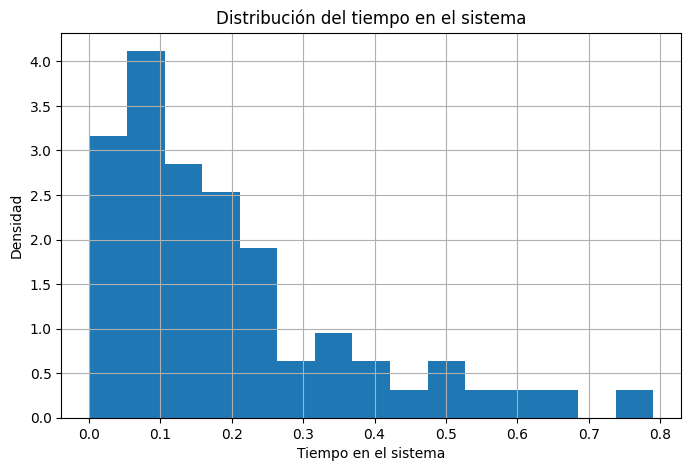

In [11]:

# GRÁFICA
# HISTOGRAMA DE TIEMPOS EN EL SISTEMA

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    tiempos_sistema,
    bins=15,
    density=True
)

plt.title("Distribución del tiempo en el sistema")
plt.xlabel("Tiempo en el sistema")
plt.ylabel("Densidad")

plt.grid(True)

plt.show()



*   **Histograma de Tiempos en el Sistema:** La distribución de los tiempos en el sistema muestra que la mayoría de los clientes experimentan tiempos de permanencia relativamente cortos, con algunos casos donde el tiempo es significativamente mayor, formando una cola hacia la derecha, típica de sistemas de colas.

**2. Llegadas y salidas de clientes**


Esta gráfica muestra cuándo llegó y salió cada cliente.

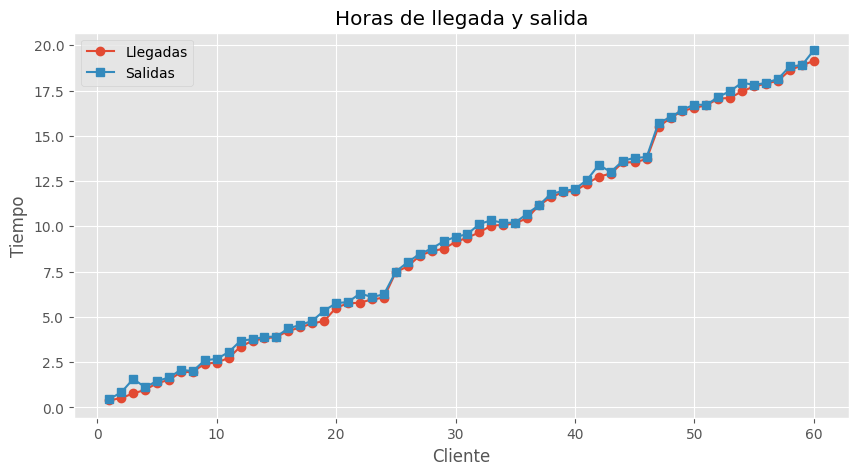

In [61]:

# GRÁFICA
# LLEGADAS Y SALIDAS

clientes = sorted(D.keys())

llegadas = [A[c] for c in clientes]
salidas  = [D[c] for c in clientes]

plt.figure(figsize=(10,5))

plt.plot(
    clientes,
    llegadas,
    marker='o',
    label='Llegadas'
)

plt.plot(
    clientes,
    salidas,
    marker='s',
    label='Salidas'
)

plt.title("Horas de llegada y salida")
plt.xlabel("Cliente")
plt.ylabel("Tiempo")

plt.legend()

plt.grid(True)

plt.show()



*   **Llegadas y Salidas de Clientes:** La gráfica de llegadas y salidas ilustra el flujo de clientes, mostrando cómo el tiempo de salida de cada cliente es consistentemente mayor que su tiempo de llegada, y cómo estas curvas se separan más cuando hay congestión.

**3. Tiempo en el sistema por cliente**

Esta suele ser la gráfica más importante para el reporte.
$$W_i​=D(i)−A(i)$$


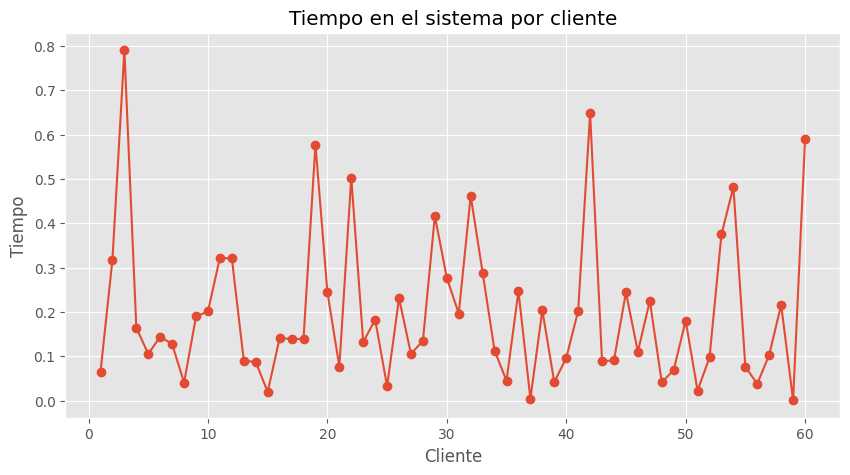

In [62]:

# GRÁFICA
# TIEMPO EN EL SISTEMA POR CLIENTE


clientes = sorted(D.keys())

W = [
    D[c] - A[c]
    for c in clientes
]

plt.figure(figsize=(10,5))

plt.plot(
    clientes,
    W,
    marker='o'
)

plt.title("Tiempo en el sistema por cliente")
plt.xlabel("Cliente")
plt.ylabel("Tiempo")

plt.grid(True)

plt.show()



*   **Tiempo en el Sistema por Cliente:** Esta gráfica visualiza la variabilidad individual del tiempo que cada cliente pasa en el sistema, corroborando las estadísticas de promedio, mínimo y máximo.

**4. Comparación entre servidores**

Permite visualizar la carga de trabajo.

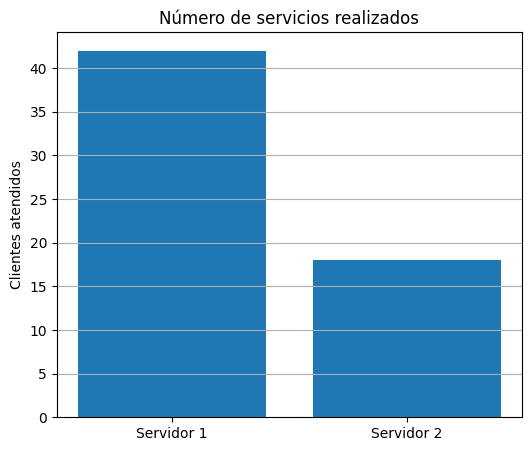

In [14]:

# GRÁFICA
# SERVICIOS REALIZADOS POR CADA SERVIDOR
=

plt.figure(figsize=(6,5))

plt.bar(
    ["Servidor 1", "Servidor 2"],
    [C1, C2]
)

plt.title("Número de servicios realizados")
plt.ylabel("Clientes atendidos")

plt.grid(axis="y")

plt.show()



*   **Servicios Realizados por Cada Servidor:** La gráfica de barras confirma la diferencia en la utilización de los servidores, con el Servidor 1 manejando una proporción mayor de clientes, como se esperaría dada la lógica de asignación.

**5. Evolución del número de clientes en el sistema**

Para esta gráfica debes registrar cada cambio de estado.

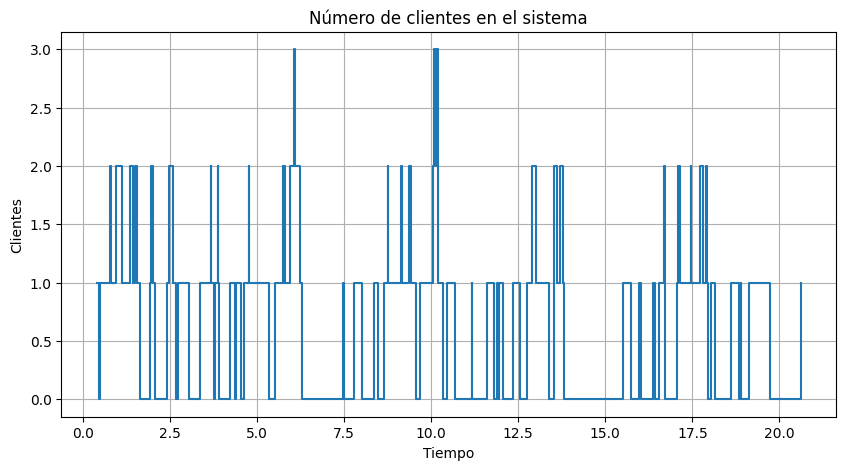

In [15]:

# GRÁFICA
# NÚMERO DE CLIENTES EN EL SISTEMA


import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.step(
    historial_t,
    historial_n,
    where="post"
)

plt.title("Número de clientes en el sistema")
plt.xlabel("Tiempo")
plt.ylabel("Clientes")

plt.grid(True)

plt.show()



*   **Evolución del Número de Clientes en el Sistema:** La gráfica paso a paso del número de clientes en el sistema a lo largo del tiempo revela los períodos de mayor ocupación y vaciado, permitiendo observar la dinámica de la cola y la capacidad de respuesta del sistema a las llegadas.

En resumen, la simulación proporciona una visión detallada del comportamiento del sistema de colas en paralelo, destacando la eficiencia general (bajo tiempo promedio en el sistema) y la distribución de la carga de trabajo entre los servidores. Estos resultados son fundamentales para la optimización de recursos y la mejora de la calidad del servicio en escenarios reales.


### <span style="color:purple;">**Conclusión** (libro de Ross)</span>


Hasta ahora, hemos ejecutado dos simulaciones de sistemas de colas: una con servidores en tándem (en serie) y otra con servidores en paralelo. Ambos modelos nos permiten entender el comportamiento de los clientes y la eficiencia de los servidores.

En la simulación en tándem, hemos observado la distribución de los tiempos totales de los clientes en el sistema y calculado el tiempo promedio. Esto nos da una idea general de cuánto tiempo esperan y son atendidos los clientes en un flujo secuencial.

Para la simulación en paralelo, hemos profundizado más, analizando no solo los tiempos promedio, máximos y mínimos en el sistema, sino también la carga de trabajo de cada servidor (Servidor 1 atendió a 42 clientes y Servidor 2 a 18, lo que indica una asignación desequilibrada o diferente capacidad/política). Hemos visualizado estos datos con varias gráficas:

Un histograma que muestra la distribución de los tiempos en el sistema para esta configuración paralela, revelando que la mayoría de los clientes tienen tiempos de permanencia relativamente cortos.
Gráficas de llegadas y salidas, y el tiempo individual en el sistema por cliente, que ilustran el flujo y la variabilidad en el servicio.
Una comparación de los servicios realizados por cada servidor, confirmando la diferencia en su utilización.
Y la evolución del número de clientes en el sistema a lo largo del tiempo, mostrando la dinámica de la cola y los momentos de mayor y menor congestión.
En resumen, ambas simulaciones nos han permitido obtener métricas clave y visualizaciones para entender cómo se comportan los clientes en diferentes arquitecturas de sistemas de colas, lo cual es fundamental para optimizar la asignación de recursos y mejorar la calidad del servicio.